![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Análisis de sentimientos y técnicas de NLP

En este taller podrán poner en práctica sus conocimientos sobre las diferentes técnicas para el procesamiento de lenguaje natural. El taller está constituido por 5 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción sentimientos de viajeros en Twitter

En este taller se usará el conjunto de datos de sentimientos sobre distintas aerolíneas de EE.UU. provenientes de Twitter. Cada observación contiene si el sentimiento de los tweets es positivo, neutral o negativo teniendo en cuenta distintas variables como aerolínea y las razones de los sentimientos negativos (como "retraso en el vuelo" o "servicio grosero"). El objetivo es predecir el sentimiento asociado a cada tweet. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/crowdflower/twitter-airline-sentiment).

**Grupo Nro 3 - Machine Learners**

Alejandra Barbosa  
Paulina Luissi  
Oscar Ardila  
Jaime Arturo Ramírez

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Importación de librerías
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

In [5]:
# Lectura de la información de archivo .zip
tweets = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/Tweets.zip', index_col=0)

# Visualización dataset
tweets.head()

,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
tweet_id,,,,,,,,,,,,,,
570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


**Documentación**  
airline_sentiment: El sentimiento del tweet (positivo, neutral o negativo)  
negativereason: Razón del sentimiento negativo (cuando aplica)  
airline: La aerolínea mencionada en el tweet  
text: El contenido del tweet  

In [10]:
# Impresión tamaño del cojunto de datos
tweets.shape

(14640, 14)

### Análisis descriptivo

In [12]:
# Cuenta de tweets por cada sentimiento
tweets['airline_sentiment'].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

In [14]:
# Cuenta de tweets por cada aerolínea
tweets['airline'].value_counts()

airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

In [16]:
# Plot con cuenta de tweets por cada aerolínea y sentimiento
pd.crosstab(index = tweets["airline"],columns = tweets["airline_sentiment"]).plot(kind='bar',figsize=(10, 6),alpha=0.5,rot=0,stacked=True,title="Sentiminetos por aerolínea")

<Axes: title={'center': 'Sentiminetos por aerolínea'}, xlabel='airline'>

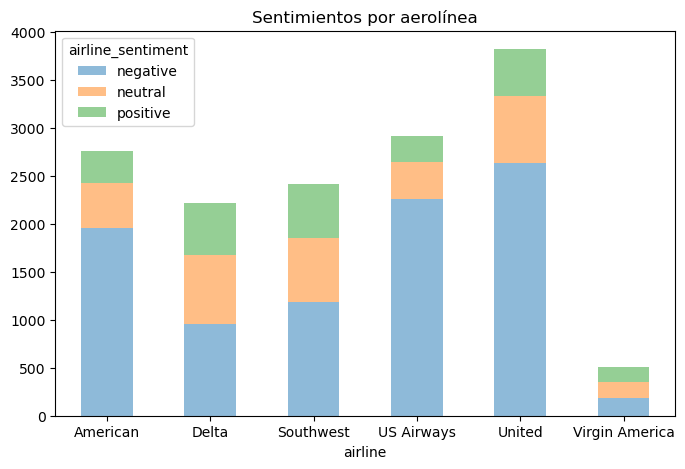

In [20]:
# Plot con cuenta de tweets por cada aerolínea y sentimiento
plot = pd.crosstab(index = tweets["airline"], columns = tweets["airline_sentiment"]).plot(
    kind='bar', 
    figsize=(8, 5), 
    alpha=0.5, 
    rot=0, 
    stacked=True, 
    title="Sentimientos por aerolínea"
)
plt.show()

**Análisis de Sentimientos**

**United Airlines:** Tiene la mayor cantidad de tweets en total y también la mayor proporción de sentimientos negativos. Aproximadamente 2/3 de sus tweets son negativos.  
**US Airways:** Muestra un patrón similar a United, con una alta proporción de tweets negativos.  
**American Airlines:** También tiene una alta proporción de comentarios negativos.  
**Delta:** Tiene una distribución más equilibrada entre los tres sentimientos, con una proporción relativamente mayor de comentarios neutrales y positivos que las otras aerolíneas principales.  
**Southwest:** Similar a Delta, tiene una proporción relativamente mayor de sentimientos positivos y neutrales comparado con las tres aerolíneas más criticadas.  
**Virgin America:** Tiene la menor cantidad de tweets en total, pero parece mantener una distribución más equilibrada de sentimientos.  

Esta visualización confirma el desbalance en los datos, donde predominan los sentimientos negativos en general. Esto es algo importante a considerar para el modelo que se desarrolle, ya que podría tener un sesgo hacia predecir sentimientos negativos.


### Liberias y Variables de interés y predicción

In [24]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from nltk.stem.snowball import SnowballStemmer
from nltk.stem import WordNetLemmatizer

In [41]:
# Separación de variables predictoras (X) y de variable de interés (y)
X = tweets['text']
y = tweets['airline_sentiment'].map({'negative':-1,'neutral':0,'positive':1})

In [43]:
# Separación de datos en set de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Uso de CountVectorizer

En la celda 1 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [45]:
# Celda 1
# Inicialización del vectorizador básico
count_vectorizer = CountVectorizer()

# Aplicación del vectorizador a los datos de entrenamiento
X_train_counts = count_vectorizer.fit_transform(X_train)

# Aplicación del mismo vectorizador a los datos de prueba
X_test_counts = count_vectorizer.transform(X_test)

# Verificar dimensiones y algunas características
print("Dimensiones de X_train_counts:", X_train_counts.shape)
print("Dimensiones de X_test_counts:", X_test_counts.shape)
print("Número de características (palabras únicas):", len(count_vectorizer.vocabulary_))

Dimensiones de X_train_counts: (9808, 12056)
Dimensiones de X_test_counts: (4832, 12056)
Número de características (palabras únicas): 12056


In [49]:
# Entrenar el modelo Random Forest y evaluar su desempeño

# Crear el modelo Random Forest con consideración del desbalanceo de clases
rf_model = RandomForestClassifier(n_estimators=100, 
                                 class_weight='balanced',
                                 random_state=42)

# Entrenar el modelo
rf_model.fit(X_train_counts, y_train)

# Predecir en el conjunto de prueba
y_pred = rf_model.predict(X_test_counts)

# Calcular la precisión del modelo
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy del modelo con CountVectorizer básico: {accuracy:.4f}")

Accuracy del modelo con CountVectorizer básico: 0.7792


**Accuracy del modelo con CountVectorizer básico: 0.7792 (77.92%)**

El modelo ha logrado una precisión cercana al 78% utilizando simplemente la representación de bolsa de palabras con CountVectorizer, sin ningún preprocesamiento adicional.

### Punto 2 - Eliminación de Stopwords

En la celda 2 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer, **eliminen stopwords** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [53]:
# Celda 2

# Eliminación de Stopwords

# Inicialización del vectorizador con eliminación de stopwords
count_vectorizer_no_stopw = CountVectorizer(stop_words='english')

# Aplicación del vectorizador a los datos de entrenamiento
X_train_counts_no_stopw = count_vectorizer_no_stopw.fit_transform(X_train)

# Aplicación del mismo vectorizador a los datos de prueba
X_test_counts_no_stopw = count_vectorizer_no_stopw.transform(X_test)

# Verificar dimensiones y características
print("Dimensiones con stopwords eliminadas:", X_train_counts_no_stopw.shape)
print("Número de características sin stopwords:", len(count_vectorizer_no_stopw.vocabulary_))


Dimensiones con stopwords eliminadas: (9808, 11777)
Número de características sin stopwords: 11777


Al eliminar stopwords, el número de características se redujo de 12,056 a 11,777, lo que significa que aproximadamente 279 palabras fueron identificadas como stopwords y eliminadas.

In [56]:
# Crear el modelo Random Forest con consideración del desbalanceo de clases (después de eliminar stopwords)

rf_model_no_stopw = RandomForestClassifier(n_estimators=100, 
                                          class_weight='balanced',
                                          random_state=42)

# Entrenar el modelo
rf_model_no_stopw.fit(X_train_counts_no_stopw, y_train)

# Predecir en el conjunto de prueba
y_pred_no_stopw = rf_model_no_stopw.predict(X_test_counts_no_stopw)

# Calcular la precisión del modelo
accuracy_no_stopw = accuracy_score(y_test, y_pred_no_stopw)
print(f"Accuracy del modelo con eliminación de stopwords: {accuracy_no_stopw:.4f}")

Accuracy del modelo con eliminación de stopwords: 0.7610


**Análisis de resultados después de eliminar Stopwords**

Vemos que el rendimiento del modelo ha disminuido ligeramente al eliminar las stopwords:

Accuracy del modelo básico: 0.7792 (77.92%)  
Accuracy del modelo sin stopwords: 0.7610 (76.10%)  

Esto indica que, en este caso particular, algunas de palabras de las stopwords podrían contener información útil para la clasificación de sentimientos. En análisis de sentimientos, palabras como "no", "must", "but" y otras stopwords podrían aportar contexto importante sobre la negación o intensidad del sentimiento. Por ello, vamos a llevar a cabo un segundo análisis con stopwords, quitando de la lista de stopwords (manualmente) palabras que consideramos pueden incidir en el resultado del modelo.

In [113]:
# Punto 2 - Versión 2. Eliminación de Stopwords con una lista ajustada

# Estamos generando una nueva lista de stopwords, quitando las palabras (de la lista de stopwords) que consideramos pueden ser importantes
# en el contexto de análisis de sentimientos. La nueva lista (constrida de manera manual) es la siguiente:

custom_stopwords= {'a', 
           'about',
           'above',
           'across',
           'after',
           'afterwards',
           'alone',
           'along',
           'already',
           'also',
           'although',
           'am',
           'among',
           'amongst',
           'amoungst',
           'an',
           'and',
           'are',
           'around',
           'as',
           'at',
           'be',
           'became',
           'become',
           'becomes',
           'becoming',
           'been',
           'beforehand',
           'behind',
           'being',
           'below',
           'beside',
           'besides',
           'between',
           'beyond',
           'bill',
           'both',
           'bottom',
           'by',
           'call',
           'co',
           'con',
           'cry',
           'de',
           'describe',
           'detail',
           'eg',
           'eight',
           'either',
           'eleven',
           'etc',
           'fifteen',
           'fifty',
           'fill',
           'find',
           'fire',
           'first',
           'five',
           'for',
           'former',
           'formerly',
           'forty',
           'found',
           'four',
           'from',
           'front',
           'full',
           'further',
           'get',
           'give',
           'go',
           'had',
           'has',
           'hasnt',
           'have',
           'he',
           'hence',
           'her',
           'here',
           'hereafter',
           'hereby',
           'herein',
           'hereupon',
           'hers',
           'herself',
           'him',
           'himself',
           'his',
           'how',
           'however',
           'hundred',
           'i',
           'ie',
           'if',
           'in',
           'inc',
           'indeed',
           'interest',
           'into',
           'is',
           'it',
           'its',
           'itself',
           'keep',
           'latter',
           'latterly',
           'ltd',
           'made',
           'me',
           'mill',
           'mine',
           'move',
           'my',
           'myself',
           'name',
           'namely',
           'nine',
           'noone',
           'of',
           'off',
           'on',
           'once',
           'one',
           'only',
           'onto',
           'or',
           'other',
           'others',
           'otherwise',
           'our',
           'ours',
           'ourselves',
           'out',
           'over',
           'own',
           'part',
           'per',
           'perhaps',
           'put',
           'rather',
           're',
           'see',
           'seem',
           'seemed',
           'seeming',
           'seems',
           'she',
           'side',
           'sincere',
           'six',
           'sixty',
           'take',
           'ten',
           'than',
           'that',
           'the',
           'their',
           'them',
           'themselves',
           'thence',
           'there',
           'thereafter',
           'thereby',
           'therein',
           'thereupon',
           'these',
           'they',
           'thick',
           'thin',
           'third',
           'this',
           'those',
           'three',
           'through',
           'throughout',
           'thru',
           'thus',
           'to',
           'together',
           'too',
           'top',
           'toward',
           'towards',
           'twelve',
           'twenty',
           'two',
           'un',
           'under',
           'until',
           'up',
           'upon',
           'us',
           'via',
           'was',
           'we',
           'well',
           'were',
           'what',
           'whatever',
           'when',
           'whence',
           'whenever',
           'where',
           'whereafter',
           'whereas',
           'whereby',
           'wherein',
           'whereupon',
           'wherever',
           'whether',
           'which',
           'while',
           'whither',
           'who',
           'whoever',
           'whole',
           'whom',
           'whose',
           'why',
           'will',
           'with',
           'within',
           'without',
           'would',
           'yet',
           'you',
           'your',
           'yours',
           'yourself',
           'yourselves'}

In [115]:

# Convertir el conjunto (set) generado (custom_stopwords) a una "lista"
custom_stopwords_list = list(custom_stopwords)

# Crear el vectorizador con la lista de stopwords personalizada
count_vectorizer_no_stopw = CountVectorizer(stop_words=custom_stopwords_list)

# Aplicar a los datos de entrenamiento
X_train_counts_no_stopw = count_vectorizer_no_stopw.fit_transform(X_train)

# Aplicar a los datos de prueba
X_test_counts_no_stopw = count_vectorizer_no_stopw.transform(X_test)

# Verificar dimensiones
print("Dimensiones con stopwords personalizadas:", X_train_counts_no_stopw.shape)
print("Número de características:", len(count_vectorizer_no_stopw.vocabulary_))

Dimensiones con stopwords personalizadas: (9808, 11862)
Número de características: 11862


La nueva lista de stopwords se aumentó de 11777 a 11862, es decir, **quitamos de la lista original de stopwords un total de 85 palabras** que consideramos podían tener un rol importante en el contexto de análisis de sentimientos en el tema de aerolíneas. 


In [117]:
# Crear el modelo Random Forest
rf_model_no_stopw = RandomForestClassifier(n_estimators=100, 
                                         class_weight='balanced',
                                         random_state=42)

# Entrenar el modelo
rf_model_no_stopw.fit(X_train_counts_no_stopw, y_train)

# Predecir en el conjunto de prueba
y_pred_no_stopw = rf_model_no_stopw.predict(X_test_counts_no_stopw)

# Calcular la precisión del modelo
accuracy_no_stopw = accuracy_score(y_test, y_pred_no_stopw)
print(f"Accuracy del modelo con stopwords personalizadas: {accuracy_no_stopw:.4f}")

Accuracy del modelo con stopwords personalizadas: 0.7715


**Análisis de resultados con stopwords "customizado"**

Como se puede observar, el resultado del accuracy fue de 77.15% versus el 76.10% del modelo de stopwords con la lista de palabras original.  

Aunque mejora el modelo, con un resultado cercano al accuracy del modelo básico (77.92%), sigue estando por debajo. La suposición que hicimos parece correcta, pero por otro lado consideramos que pueden haber otras métricas, diferente del accuracy, que demuestren las bondades del modelo de stopwords.

### Punto 3 - Lematización con verbos

En la celda 3 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer, **lematizen el texto con verbos** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [60]:
# Celda 3
# Lematización con verbos
# Para este punto, se necesita crear una función personalizada que aplique lematización a las palabras

# Se importa WordNetLemmatizer
import nltk
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

# Inicialización del lematizador
wordnet_lemmatizer = WordNetLemmatizer()

# Definición de función para lematización con verbos
def lemmatize_text(text):
    text = text.lower()
    words = text.split()
    return ' '.join([wordnet_lemmatizer.lemmatize(word, pos='v') for word in words])

# Crear un vectorizador con el lematizador
count_vectorizer_lemma = CountVectorizer(preprocessor=lemmatize_text)

# Aplicación del vectorizador a los datos
X_train_counts_lemma = count_vectorizer_lemma.fit_transform(X_train)
X_test_counts_lemma = count_vectorizer_lemma.transform(X_test)

# Verificar dimensiones
print("Dimensiones con lematización de verbos:", X_train_counts_lemma.shape)
print("Número de características con lematización:", len(count_vectorizer_lemma.vocabulary_))

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jaime\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Dimensiones con lematización de verbos: (9808, 11248)
Número de características con lematización: 11248


La lematización ha reducido el número de características a 11,248, lo cual es una reducción significativa comparada con el modelo original (12,056) y el modelo sin stopwords (11,777). Esto sugiere que la lematización está normalizando diferentes formas verbales a una forma base común, lo que podría ayudar al modelo a identificar patrones más generales.

In [63]:
# Crear el modelo Random Forest
rf_model_lemma = RandomForestClassifier(n_estimators=100, 
                                       class_weight='balanced',
                                       random_state=42)

# Entrenar el modelo
rf_model_lemma.fit(X_train_counts_lemma, y_train)

# Predecir en el conjunto de prueba
y_pred_lemma = rf_model_lemma.predict(X_test_counts_lemma)

# Calcular la precisión del modelo
accuracy_lemma = accuracy_score(y_test, y_pred_lemma)
print(f"Accuracy del modelo con lematización de verbos: {accuracy_lemma:.4f}")

Accuracy del modelo con lematización de verbos: 0.7802


**Análisis de resultados con lematización**

La lematización de verbos ha mejorado ligeramente el rendimiento del modelo original:

Accuracy del modelo básico: 0.7792 (77.92%)  
Accuracy del modelo sin stopwords: 0.7610 (76.10%)  
Accuracy del modelo sin stopwords customizado: 0.7715 (77.15%)  
Accuracy del modelo con lematización de verbos: 0.7802 (78.02%)

### Punto 4 - Multiples técnicas

En la celda 4 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer, eliminen stopwords, lematizen el texto con verbos** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [75]:
# Celda 4
# Múltiples técnicas (stopwords + lematización con verbos)

# Se descarga stopwords
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

# Función para lematizar y eliminar stopwords
def lemmatize_text_no_stopw(text):
    # Primero se realiza la lematización
    text = text.lower()
    words = text.split()
    lemmatized = [wordnet_lemmatizer.lemmatize(word, pos='v') for word in words]
    
    # Filtramos las stopwords
    filtered = [word for word in lemmatized if word not in stop_words]
    
    return ' '.join(filtered)

# Crear vectorizador con ambas técnicas
count_vectorizer_combined = CountVectorizer(preprocessor=lemmatize_text_no_stopw)

# Aplicar a los datos
X_train_counts_combined = count_vectorizer_combined.fit_transform(X_train)
X_test_counts_combined = count_vectorizer_combined.transform(X_test)

# Verificar dimensiones
print("Dimensiones con lematización + eliminación de stopwords:", X_train_counts_combined.shape)
print("Número de características con ambas técnicas:", len(count_vectorizer_combined.vocabulary_))

Dimensiones con lematización + eliminación de stopwords: (9808, 11231)
Número de características con ambas técnicas: 11231


In [77]:
# Crear el modelo Random Forest
rf_model_combined = RandomForestClassifier(n_estimators=100, 
                                         class_weight='balanced',
                                         random_state=42)

# Entrenar el modelo
rf_model_combined.fit(X_train_counts_combined, y_train)

# Predecir en el conjunto de prueba
y_pred_combined = rf_model_combined.predict(X_test_counts_combined)

# Calcular la precisión del modelo
accuracy_combined = accuracy_score(y_test, y_pred_combined)
print(f"Accuracy del modelo con lematización + eliminación de stopwords: {accuracy_combined:.4f}")

Accuracy del modelo con lematización + eliminación de stopwords: 0.7726


**Análisis de resultados del modelo combinado de stopwords + lematización con verbos**

Comparando los resultados hasta ahora:

Modelo básico (solo CountVectorizer): 77.92%  
Eliminación de stopwords: 76.10%  
Accuracy del modelo sin stopwords customizado: 0.7715 (77.15%)  
Lematización de verbos: 78.02%  
Lematización + eliminación de stopwords: 77.26%  

Se observa que la lematización por sí sola ha dado el mejor resultado hasta ahora (78.02%). Cuando combinamos ambas técnicas, el rendimiento baja ligeramente. Esto puede indicar que al eliminar stopwords se está perdiendo información contextual importante para la clasificación de sentimientos.

### Punto 5 - Comparación y análisis de resultados

En la celda 5 comparen los resultados obtenidos de los diferentes modelos (random forest) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

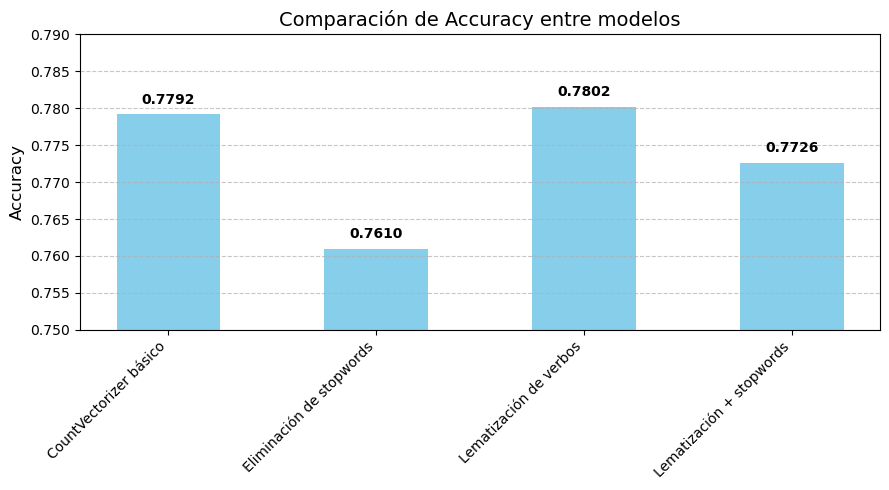


Análisis de resultados:
--------------------------------------------------
El mejor modelo es la Lematización de verbos con un accuracy de 0.7802
El peor modelo es la Eliminación de stopwords con un accuracy de 0.7610
--------------------------------------------------


In [89]:
# Celda 5
# Crear un gráfico de barras mejorado para visualizar los resultados
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9, 5))

# Convertir accuracy a valores flotantes para graficar
accuracy_values = results_df['Accuracy'].astype(float)
models = results_df['Modelo']

# Crear barras más estrechas (width=0.5)
bar_positions = np.arange(len(models))
bars = plt.bar(bar_positions, accuracy_values, width=0.5, color='skyblue')

# Añadir valores en la parte superior de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
            f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

plt.title('Comparación de Accuracy entre modelos', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(bar_positions, models, rotation=45, ha='right', fontsize=10)
plt.ylim(0.75, 0.79)  # Ajustar el rango del eje Y para ver mejor las diferencias
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Análisis escrito de los resultados
print("\nAnálisis de resultados:")
print("-" * 50)
print(f"El mejor modelo es la Lematización de verbos con un accuracy de {max(accuracy_values):.4f}")
print(f"El peor modelo es la Eliminación de stopwords con un accuracy de {min(accuracy_values):.4f}")
print("-" * 50)

**Análisis Comparativo de Modelos de Sentiment Analysis**

Tras evaluar cuatro técnicas de procesamiento de texto combinadas con Random Forest para analizar sentimientos en tweets sobre aerolíneas, el modelo con **mejor desempeño fue el que utilizó lematización de verbos**, alcanzando un 78.02% de precisión. Consideramos que su **principal ventaja está en la capacidad de reducir variantes verbales a su forma base sin sacrificar significado semántico**, permitiendo al modelo reconocer patrones similares independientemente de la conjugación utilizada. Esta normalización redujo la dimensionalidad del vocabulario (de 12,056 a 11,248 características), pero preservando información importante sobre actitudes y emociones expresadas mediante acciones.  

Por el contrario, el **modelo con eliminación de stopwords mostró el peor rendimiento (76.10%)**. Aunque se hubiera esperado que el accuracy mejorara, suponemos que se debería utilizar otros indicadores que permitieran validar las ventajas de este método. Sin embargo, al ejecutar stopwords, supusimos que que al eliminarse palabras funcionales como "no", "must", "but" o muchas otras, se descartaba información contextual esencial para determinar la polaridad del sentimiento, pero al hacerlo (como se puede validar), mejoró el resultado del accuracy, pero no fue mejor que el modelo básico. En particular, **el resultado del accuracy con el stopwords customizado fue de 77.15% versus el 76.10% del modelo de stopwords con la lista de palabras original**. Aunque mejora el modelo, sigue estando por debajo del modelo básico.  

El modelo básico con CountVectorizer (77.92%) y la combinación de lematización y eliminación de stopwords (77.26%) obtuvieron resultados intermedios. Esto refuerza la observación de que, para análisis de sentimientos, mantener la estructura contextual es más importante que reducir la dimensionalidad. La lematización permitió un buen balance entre normalización y preservación semántica, particularmente útil para capturar expresiones emocionales en mensajes cortos como tweets.
